# Data Preprocessing

In [31]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

from sklearn.neighbors import KNeighborsClassifier 
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier 
from xgboost import XGBClassifier 
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression


from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

**Import the CSV Data as Pandas DataFrame** 

In [32]:
df = pd.read_csv('data/covtype.csv')
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


### Data Cleaning

Checking features with nan values

In [33]:
features_with_na = [feature for feature in df.columns if df[feature].isnull().sum()>=1]
for feature in features_with_na:
    print(feature, np.round(df[feature].isnull().mean(),4), '% missing values')

**Handling DUplicates**

In [34]:
df.duplicated().sum()

np.int64(0)

## Feature Engineering

In [35]:
# Type of features
#NUMERIC FEATURES
numeric_features = [feature for feature in df.columns if df[feature].dtype !='O']
print('Number of numerical features: ', len(numeric_features))

Number of numerical features:  55


In [36]:
#CATEGORICAL FEATURES
categorical_features = [feature for feature in df.columns if df[feature].dtype =='O']
print('Number of categorical features: ', len(categorical_features))

Number of categorical features:  0


In [37]:
#DISCRETE FEATURES
discrete_features = [feature for feature in numeric_features if len(df[feature].unique())<=25]
print('Number of discrete features: ', len(discrete_features))

Number of discrete features:  45


In [38]:
#CONTINUOUS FEATURES
continuous_features = [feature for feature in numeric_features if feature not in discrete_features]
print('Number of continuous features: ', len(continuous_features))

Number of continuous features:  10


### Check Outlier and capping it

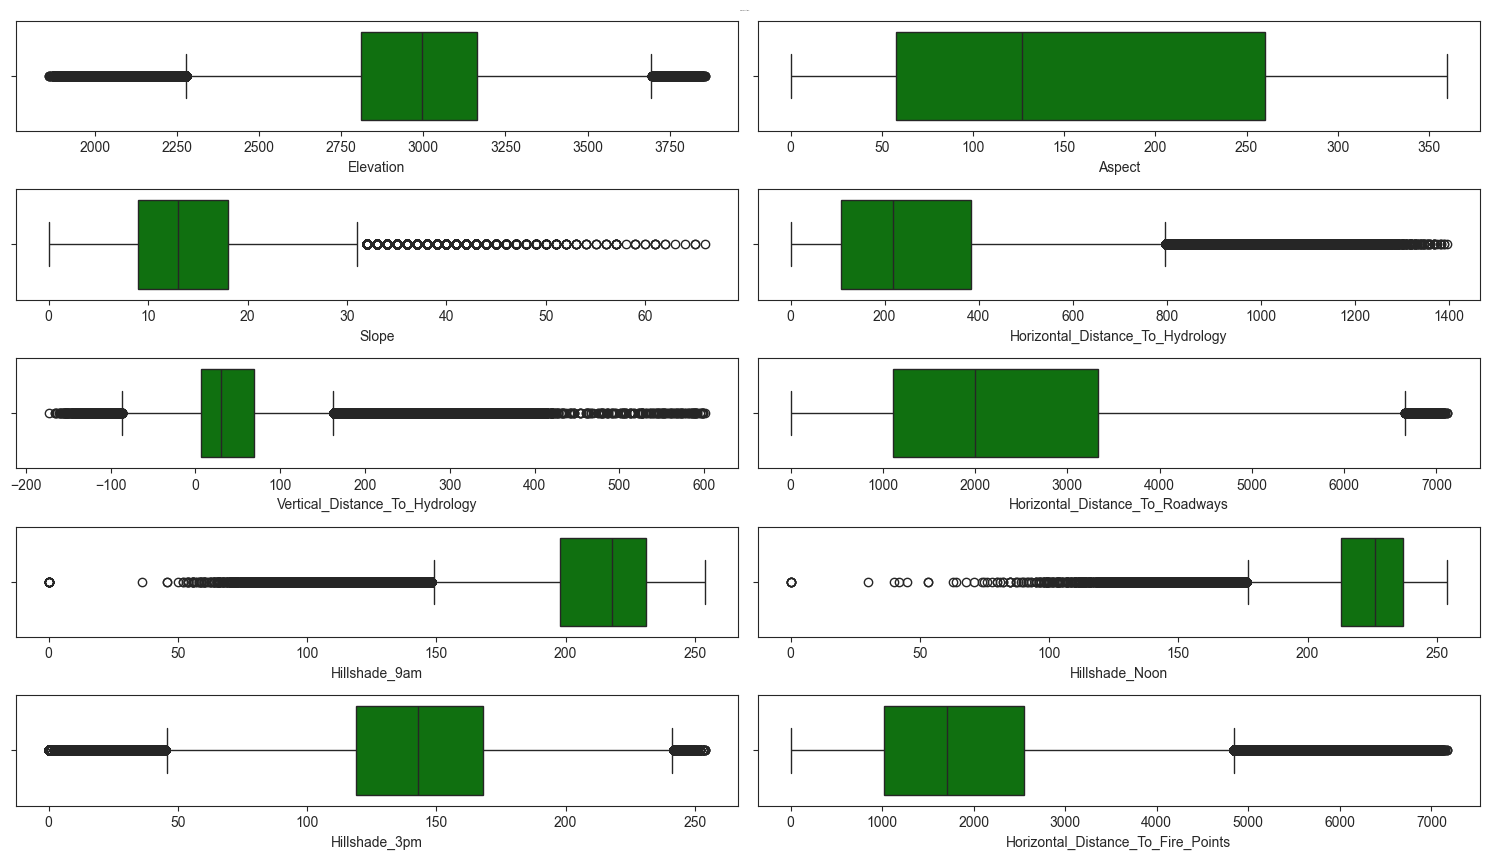

In [39]:
plt.figure(figsize=(15,10))
plt.suptitle('Check Outliers', fontsize=0)
for i in range(0, len(continuous_features)):
    plt.subplot(6,2,i+1)
    sns.set_style('ticks')
    sns.boxplot(df[continuous_features[i]], color='green', orient='h')
    plt.tight_layout()

Insight
* Except 'Aspect' rest all other 9 continuous features has outliers

In [40]:
df_copy = df.copy()
def detect_and_capping_outliers(col):
    percentile25 = df_copy[col].quantile(0.25)
    percentile75 = df_copy[col].quantile(0.75)
    iqr = percentile75 - percentile25
    upper_limit = percentile75 + (1.5 * iqr)
    lower_limit = percentile25 - (1.5 * iqr)
    df_copy.loc[(df_copy[col]>upper_limit), col] = upper_limit
    df_copy.loc[(df_copy[col]<lower_limit), col] = lower_limit      
    return df_copy


In [41]:
for col in continuous_features:
    detect_and_capping_outliers(col)

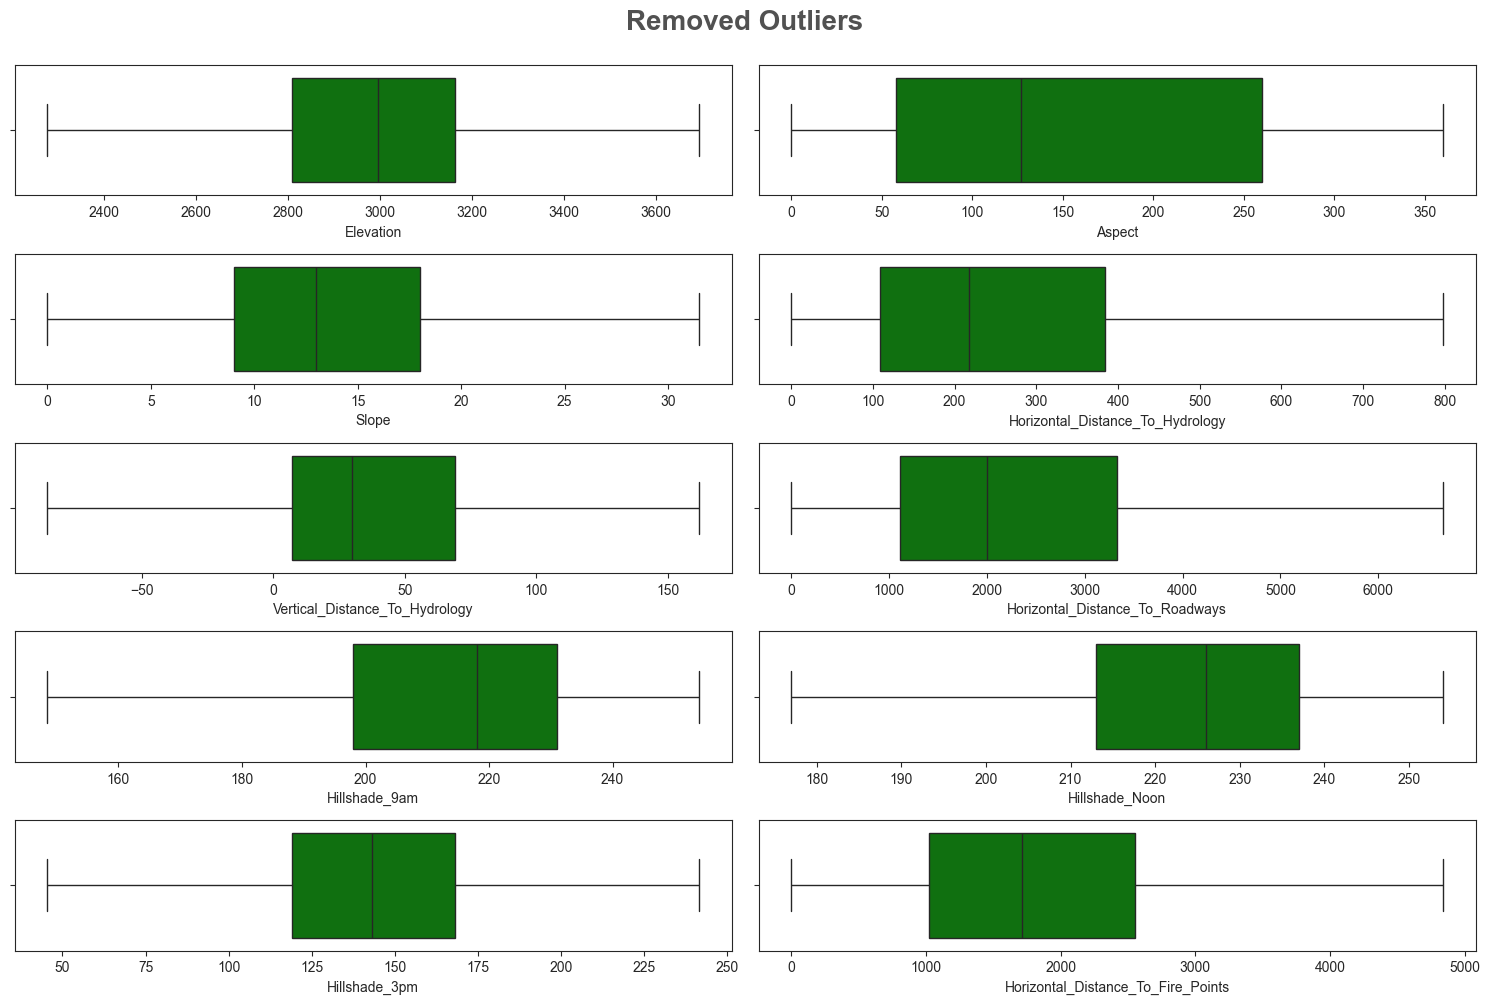

In [42]:
plt.figure(figsize=(15, 10))
plt.suptitle('Removed Outliers', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
for i in range(0, len(continuous_features)):
    plt.subplot(5,2,i+1)
    sns.set_style('ticks')
    sns.boxplot(df_copy[continuous_features[i]], color='green', orient='h')
    plt.tight_layout()

Create one column as Wilderness_Area_Type and represent it as categorical data

In [43]:
df['Wilderness_Area1'] = (df.iloc[:, 10:15]==1).idxmax(1)
wilderness_areas = sorted(df['Wilderness_Area1'].value_counts().index.tolist())

In [44]:
wilderness_areas

['Wilderness_Area1',
 'Wilderness_Area2',
 'Wilderness_Area3',
 'Wilderness_Area4']

In [45]:
def split_numbers_chars(row):
    '''This function fetches the numerical characters at the end of the string and returns alphabetical character and numerical character respectively'''
    head = row.rstrip('0123456789')
    tail = row[len(head):]
    return head, tail

def reverse_one_hot_encode(dataframe, start_loc, end_loc, numeric_column_name):
    '''This function reverse one hot encodes the categorical features'''
    dataframe['String_Column'] = (dataframe.iloc[:, start_loc:end_loc]==1).idxmax(1)
    dataframe['Tuple_Column'] = dataframe['String_Column'].apply(split_numbers_chars)
    dataframe[numeric_column_name] = dataframe['Tuple_Column'].apply(lambda x:x[1]).astype('int64')
    dataframe.drop(columns=['String_Column','Tuple_Column'], inplace = True)

In [46]:
df_copy = df.copy()
reverse_one_hot_encode(df_copy, 14, 56, 'Soil_Type')

In [50]:
feature_names = continuous_features + wilderness_areas + ["Soil_Type"] + ["Cover_Type"]
all_features_df = df_copy[feature_names]
all_features_df

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Soil_Type,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,Wilderness_Area1,0,0,0,29,5
1,2590,56,2,212,-6,390,220,235,151,6225,Wilderness_Area1,0,0,0,29,5
2,2804,139,9,268,65,3180,234,238,135,6121,Wilderness_Area1,0,0,0,12,2
3,2785,155,18,242,118,3090,238,238,122,6211,Wilderness_Area1,0,0,0,30,2
4,2595,45,2,153,-1,391,220,234,150,6172,Wilderness_Area1,0,0,0,29,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396,153,20,85,17,108,240,237,118,837,Wilderness_Area3,0,1,0,2,3
581008,2391,152,19,67,12,95,240,237,119,845,Wilderness_Area3,0,1,0,2,3
581009,2386,159,17,60,7,90,236,241,130,854,Wilderness_Area3,0,1,0,2,3
581010,2384,170,15,60,5,90,230,245,143,864,Wilderness_Area3,0,1,0,2,3


### Visualize the Class Distribution

In [51]:
all_features_df['Cover_Type'] = all_features_df['Cover_Type']-1

In [52]:
all_features_df['Cover_Type'].value_counts()

Cover_Type
1    283301
0    211840
2     35754
6     20510
5     17367
4      9493
3      2747
Name: count, dtype: int64

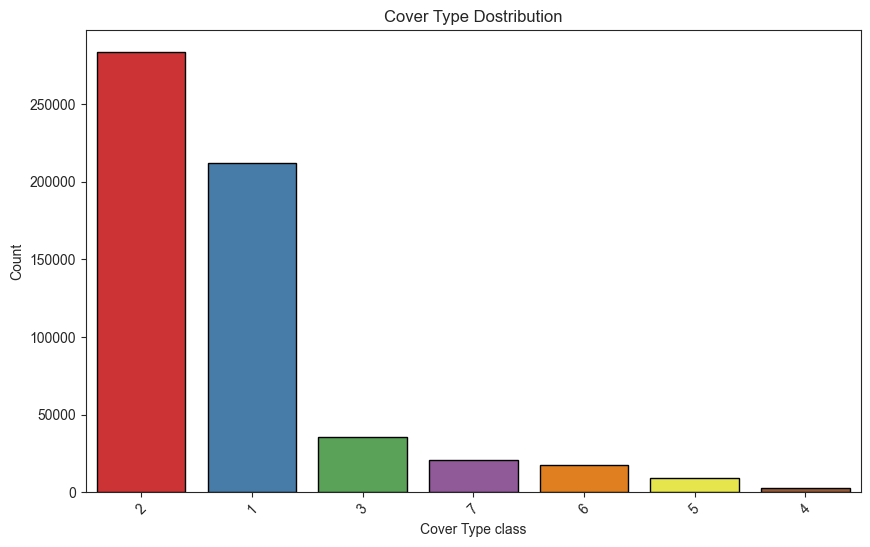

In [57]:
plt.subplots(figsize=(10, 6))
sns.countplot(x='Cover_Type', data = df, ec = 'black', palette='Set1', order = df['Cover_Type'].value_counts().index)
plt.title("Cover Type Dostribution")
plt.ylabel("Count")
plt.xlabel("Cover Type class" )
plt.xticks(rotation=45)
plt.show()

Inference
* As most of the data is of class 0 and class 1 type 
* So its a clear case of imbalance